# Basic setup

In [88]:
import numpy as np
import pandas as pd
import pingouin as pg
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.power import TTestPower
from statsmodels.stats.proportion import proportions_ztest
from sklearn.metrics import mean_squared_error
from sklearn import linear_model
import seaborn as sns
import matplotlib.pyplot as plt
from palmerpenguins import load_penguins

In [2]:
sns.set_theme(style="whitegrid", palette="Set2")

In [3]:
data = pd.DataFrame()
data = load_penguins()

# Exploration

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


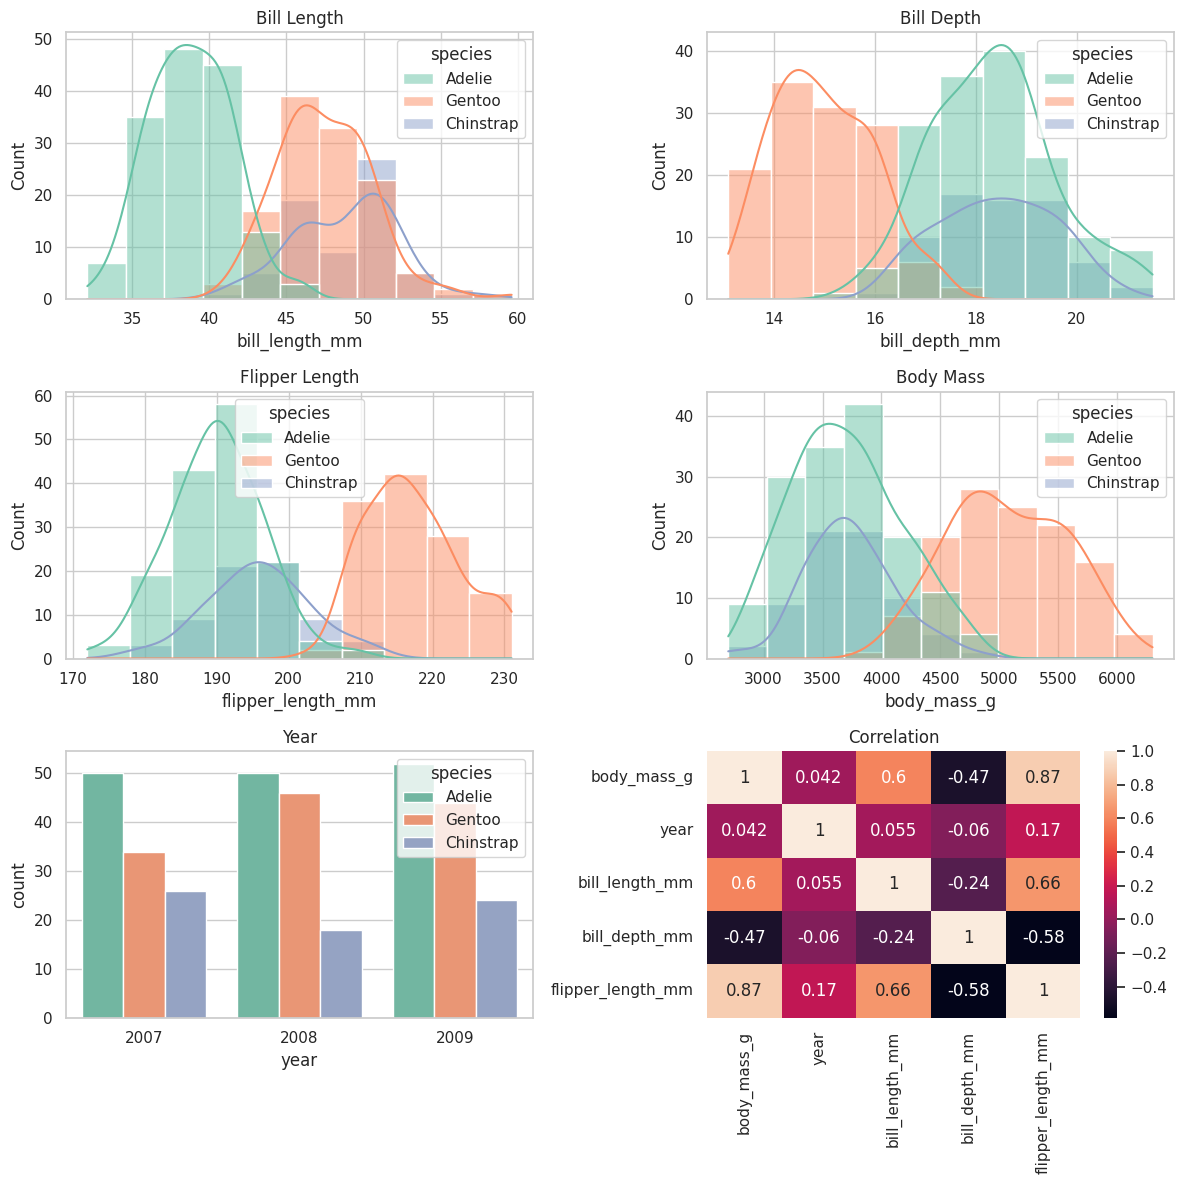

In [5]:
# Ax level plots

fig, ax = plt.subplots(3, 2, figsize=(12, 12))

sns.histplot(data, x="bill_length_mm", hue="species", kde=True, ax=ax[0,0])
ax[0,0].set_title('Bill Length')

sns.histplot(data, x="bill_depth_mm", hue="species", kde=True, ax=ax[0,1])
ax[0,1].set_title('Bill Depth')

sns.histplot(data, x="flipper_length_mm", hue="species", kde=True, ax=ax[1,0])
ax[1,0].set_title('Flipper Length')

sns.histplot(data, x="body_mass_g", hue="species", kde=True, ax=ax[1,1])
ax[1,1].set_title('Body Mass')

sns.countplot(data, x="year", hue="species", ax=ax[2,0])
ax[2,0].set_title('Year')

sns.heatmap(data.loc[:, ['body_mass_g', 'year', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']].corr(), annot=True, ax=ax[2,1])
ax[2,1].set_title('Correlation')

plt.tight_layout()
plt.show()

# Experiments

## Statistical power

An A/B testing experiment is being developed to see if a new diet could increase the weight of the Adelie species by 100 grams. What is the statistical power if we can only sample 200 penguins?

In [6]:
# Adelie species parameters
ade_mean = np.mean(data.query('species == "Adelie"').body_mass_g)
ade_std = np.std(data.query('species == "Adelie"').body_mass_g, ddof=1) # degree of freedom = n - 1 since we are using the sample from the dataset
alpha = 0.05
target_weight = 3800
sample = 200

print(f'The mean weight of Adelie penguins is {ade_mean:,.2f} grams and the standard deviation is {ade_std:,.2f} grams.')

The mean weight of Adelie penguins is 3,700.66 grams and the standard deviation is 458.57 grams.


In [7]:
# Manual calculation

sem = ade_std / np.sqrt(sample)
x_critical = ade_mean + sem * stats.t.ppf(1 -alpha, df=sample - 1)
t_score = (x_critical - target_weight) / sem
power = stats.t.sf(t_score, df=sample - 1)

print(f'The statistical power is {power:.4%}')

The statistical power is 92.0100%


If the A/B experiment's goal is to identify a small difference in weight, the number of samples would have to be higher

In [8]:
# Using the package

# One important difference is that the Cohen's d must be calculatted
cohen_d = float((target_weight - ade_mean) / ade_std)

# Calculating the statistical power
power_analysis = TTestPower()
solution = power_analysis.solve_power(effect_size=cohen_d, nobs=sample, alpha=alpha, alternative='larger')
print(f'The statistical power is {solution:.4%}')

# If I would like to know the sample size based on a desired power of 80%
sample_size = power_analysis.solve_power(power=0.90, effect_size=cohen_d, alpha=alpha, alternative='larger')
print(f'\nThe sample size required is {sample_size:.0f}')

The statistical power is 92.0475%

The sample size required is 184


## Hypothesis testing

### Hypothesis testing of the mean - One sample

In the 90's, the average gentoo penguin weight was 4.9 Kg. Has this change based on the sample?

In [9]:
# Manual calculation
gentoo_mean = data.query('species == "Gentoo"').body_mass_g.mean()
print(f'The average Gentoo penguin weight was {gentoo_mean:,.2f} grams')
gentoo_size = data.query('species == "Gentoo"').shape[0]
gentoo_std = np.std(data.query('species == "Gentoo"').body_mass_g, ddof=1)
h0 = 4900

sem = gentoo_std / np.sqrt(gentoo_size)
t_test = (gentoo_mean - h0) / sem
p_value = stats.t.sf(np.abs(t_test), df=gentoo_size - 1) * 2 # Two-sided test
print(f'The p-value is {p_value:.4%}. Hence, H0 is rejected and conclude that the average weight of Gentoo penguins has changed from {h0} grams.')


The average Gentoo penguin weight was 5,076.02 grams
The p-value is 0.0164%. Hence, H0 is rejected and conclude that the average weight of Gentoo penguins has changed from 4900 grams.


In [10]:
# Using the package

t_stat, p_value = stats.ttest_1samp(a=data.query('species == "Gentoo"')['body_mass_g'].dropna(), popmean=4900, alternative='two-sided')
print(f'The t statistic is {t_stat} and the p_value is {p_value:.4%}.')

The t statistic is 3.872350495988591 and the p_value is 0.0175%.


Hence, H0 is rejected and the average weight of the Gentoo penguins has changes since the 90s

In [11]:
# Just in case, checking the statistical power
# THIS IS A WRONG APPROACH AS THE SAMPLE DATA IS BEING USED. INSTEAD, THE CONFIDENCE INTERVAL COULD BE EFFECTIVE

cohen_d = float(gentoo_mean - h0) / gentoo_std

# Calculating the statistical power
power_analysis = TTestPower()
statistical_power = power_analysis.solve_power(effect_size=cohen_d, nobs=gentoo_size, alpha=0.05, alternative='two-sided')
print(f'The statistical power is {statistical_power:.4%}.')

The statistical power is 97.1123%.


### Hypothesis testing of the mean - Two samples

This test is basially to understand if wheter 2 samples come from the same population

Is there a statistically significant difference in the average body mass of Adelie penguins living on Torgersen Island compared to those on Biscoe Island?

In [12]:
sample1 = data[(data.species == 'Adelie') & (data.island == 'Torgersen')].body_mass_g.dropna()
sample2 = data[(data.species == 'Adelie') & (data.island == 'Biscoe')].body_mass_g.dropna()

t_stat, p_value = stats.ttest_ind(sample1, sample2, equal_var=False, alternative='two-sided')
# equal_var = False means to use Welch's t-test' which does not assume equal variance
print(f'The t statistic is {t_stat} and the p_value is {p_value:.4%}.')

The t statistic is -0.034096013235371626 and the p_value is 97.2878%.


These 2 samples from Adelie penguins from two different islands show that they come from the population as there is no significant difference in their average eight

### Hypothesis testing of the mean - More than two samples

Is there a significant difference in the mean weight across the three different species?

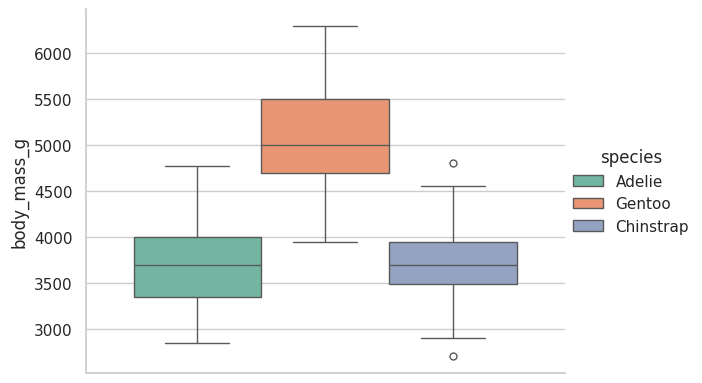

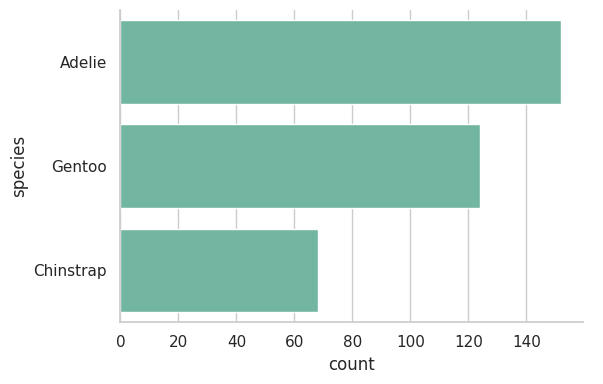

In [13]:
# Checking if there are severe outliers

sns.catplot(data=data, y='body_mass_g', kind='box', height=4, aspect=1.5, hue='species', palette='Set2')

# Checking the sample size
sns.catplot(data=data, y='species', kind='count', height=4, aspect=1.5)

In [14]:
group_one = data[data.species == 'Adelie'].body_mass_g.dropna()
group_two = data[data.species == 'Gentoo'].body_mass_g.dropna()
group_three = data[data.species == 'Chinstrap'].body_mass_g.dropna()

f_statistic, p_value = stats.f_oneway(group_one, group_two, group_three, equal_var=False)
print(f'The F statistic is {f_statistic} and the p_value is {p_value:.4%}.')

The F statistic is 317.572267104156 and the p_value is 0.0000%.


There is a significant difference to conclude that the mean weight across the pengu's species is different

In [15]:
posthoc_results = pg.pairwise_gameshowell(data=data, dv='body_mass_g', between='species')
print(posthoc_results[['A', 'B', 'mean_A', 'mean_B', 'diff', 'pval']])

           A          B       mean_A       mean_B         diff          pval
0     Adelie  Chinstrap  3700.662252  3733.088235   -32.425984  8.501540e-01
1     Adelie     Gentoo  3700.662252  5076.016260 -1375.354009  0.000000e+00
2  Chinstrap     Gentoo  3733.088235  5076.016260 -1342.928025  4.729550e-14


Gemini examples:

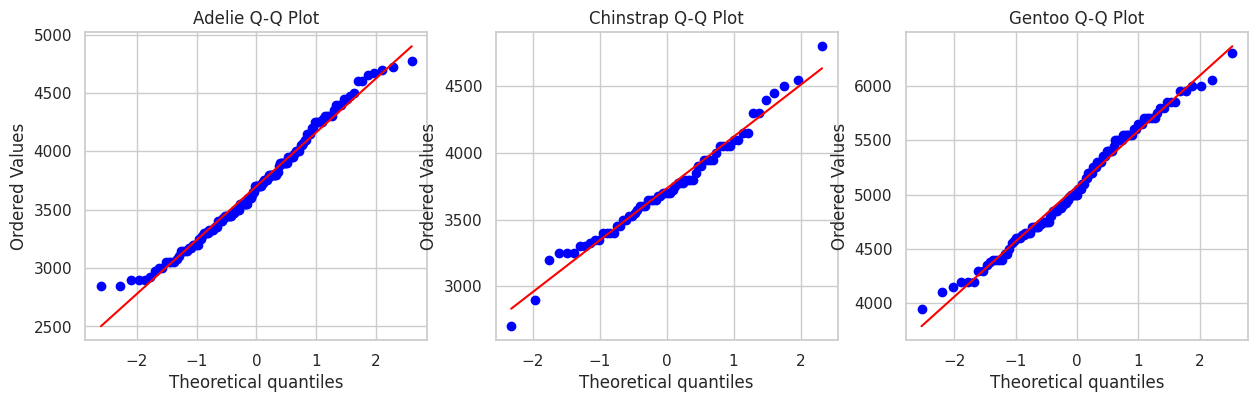

Adelie Shapiro P-value: 0.0324
Chinstrap Shapiro P-value: 0.5605
Gentoo Shapiro P-value: 0.2336


In [16]:
# 1. Extract the 3 groups
adelie = data.query('species == "Adelie"').body_mass_g.dropna()
chinstrap = data.query('species == "Chinstrap"').body_mass_g.dropna()
gentoo = data.query('species == "Gentoo"').body_mass_g.dropna()

# 2. The Visual Test: Q-Q Plots
# A Q-Q plot forces perfectly normal data to form a straight 45-degree diagonal line.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
stats.probplot(adelie, dist="norm", plot=axes[0])
axes[0].set_title('Adelie Q-Q Plot')

stats.probplot(chinstrap, dist="norm", plot=axes[1])
axes[1].set_title('Chinstrap Q-Q Plot')

stats.probplot(gentoo, dist="norm", plot=axes[2])
axes[2].set_title('Gentoo Q-Q Plot')
plt.show()

# 3. The Math Test: Shapiro-Wilk
# H0: The data is perfectly normal. (We WANT the P-value to be > 0.05!)
print(f"Adelie Shapiro P-value: {stats.shapiro(adelie).pvalue:.4f}")
print(f"Chinstrap Shapiro P-value: {stats.shapiro(chinstrap).pvalue:.4f}")
print(f"Gentoo Shapiro P-value: {stats.shapiro(gentoo).pvalue:.4f}")

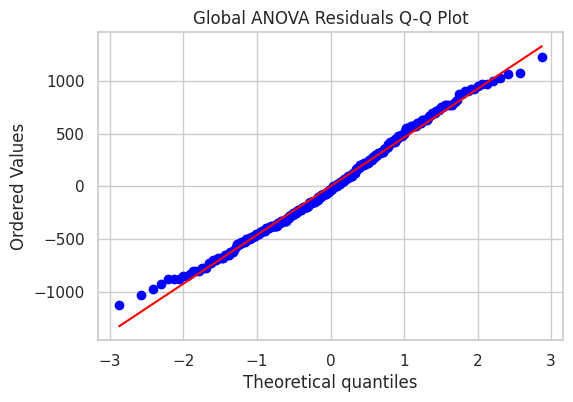

Global Residuals Shapiro P-value: 0.0512


In [17]:
# Residual validation (best option)

from statsmodels.formula.api import ols

# 1. Build the ANOVA Model (The GLM Engine)
# "Predict body_mass_g using the Categorical (C) variable 'species'"
model = ols('body_mass_g ~ C(species)', data=data).fit()

# 2. Extract the Universal Residuals
# The model calculates every single penguin's distance from its group mean
global_residuals = model.resid

# 3. The Visual Test (One Q-Q Plot for the whole model)
fig, ax = plt.subplots(figsize=(6, 4))
stats.probplot(global_residuals, dist="norm", plot=ax)
ax.set_title('Global ANOVA Residuals Q-Q Plot')
plt.show()

# 4. The Math Test (One Shapiro Test for the whole model)
shapiro_test = stats.shapiro(global_residuals)
print(f"Global Residuals Shapiro P-value: {shapiro_test.pvalue:.4f}")

In [18]:
# Pingouin automatically defaults to Welch's ANOVA!
anova_results = pg.welch_anova(dv='body_mass_g', between='species', data=data)

print(anova_results)

    Source  ddof1       ddof2           F         p_unc       np2
0  species      2  189.478413  317.572267  3.093701e-61  0.669672


### Hypothesis testing for proportions - One sample

In the 80's census, Adelie penguins represented 60% of the population. Is that proportion still correct given the collected samples?

In [19]:
nobs = data.species.shape[0]
count = data.query('species == "Adelie"').shape[0]
value = 0.6

z_stat, p_value = proportions_ztest(count, nobs, value, alternative='two-sided')
# alternative could be 'larger', 'smaller' or 'two-sided'

print(f"Z-Statistic: {z_stat:.2f}")
print(f"P-Value: {p_value:.4%}")

Z-Statistic: -5.91
P-Value: 0.0000%


In [20]:
# For reference on the species proportions

data.species.value_counts(normalize=True)

species
Adelie       0.441860
Gentoo       0.360465
Chinstrap    0.197674
Name: proportion, dtype: float64

No, the null hypothesis ia rejected

### Hypothesis testing for proportions - Two samples

There is only budget to study Adelie penguins on one island. So a decision has to be made between the islands Dream and Biscoe

In [21]:
# How many Adelie penguins are on Dream Island and Biscoe Island?
adelei_dream = data[(data.island == 'Dream') & (data.species == 'Adelie')].shape[0]
adelei_biscoe = data[(data.island == 'Biscoe') & (data.species == 'Adelie')].shape[0]

# How many penguins are on each island?
dream_penguins = data.query('island == "Dream"').dropna(subset=['species']).shape[0]
biscoe_penguins = data.query('island == "Biscoe"').dropna(subset=['species']).shape[0]

print(f"Adelie penguins on Dream Island: {adelei_dream} and on Biscoe Island: {adelei_biscoe}")
print(f"Total penguins on Dream Island: {dream_penguins} and on Biscoe Island: {biscoe_penguins}")
print(f"\nProportion of Adelie penguins on Dream Island: {adelei_dream / dream_penguins:.2%}")
print(f"Proportion of Adelie penguins on Biscoe Island: {adelei_biscoe / biscoe_penguins:.2%}\n")

# Formatting the results
counts = np.array([adelei_dream, adelei_biscoe])
total = np.array([dream_penguins, biscoe_penguins])

# Running the test
z_stat, p_value = proportions_ztest(count=counts, nobs=total, alternative='two-sided')
print(f"Z-Statistic: {z_stat:.2f} and P-Value: {p_value:.4%}")

Adelie penguins on Dream Island: 56 and on Biscoe Island: 44
Total penguins on Dream Island: 124 and on Biscoe Island: 168

Proportion of Adelie penguins on Dream Island: 45.16%
Proportion of Adelie penguins on Biscoe Island: 26.19%

Z-Statistic: 3.38 and P-Value: 0.0734%


In [22]:
# Switching the order of the values

# Formatting the results
counts = np.array([adelei_biscoe, adelei_dream, ])
total = np.array([biscoe_penguins, dream_penguins])

# Running the test
z_stat, p_value = proportions_ztest(count=counts, nobs=total, alternative='two-sided')
print(f"Z-Statistic: {z_stat:.2f} and P-Value: {p_value:.4%}")

Z-Statistic: -3.38 and P-Value: 0.0734%


In [23]:
# Using a different value on the alternative

# Formatting the results
counts = np.array([adelei_biscoe, adelei_dream, ])
total = np.array([biscoe_penguins, dream_penguins])

# Running the test
z_stat, p_value = proportions_ztest(count=counts, nobs=total, alternative='larger')
# H0: dream > biscoe
print(f"Z-Statistic: {z_stat:.2f} and P-Value: {p_value:.4%}")

Z-Statistic: -3.38 and P-Value: 99.9633%


### Hypothesis testing - Test of homegeinity

Is the ratio of male-female the same across all the islands?

In [24]:
island_sex = data.groupby(['island', 'sex']).size().unstack().fillna(0)
print(island_sex)

chi_statistic, p_value, dof, blueprint_matrix= stats.chi2_contingency(island_sex)
print(f"\nChi-Square Test: {chi_statistic:.2f} and P-Value: {p_value:.4%}")
print(blueprint_matrix)


sex        female  male
island                 
Biscoe         80    83
Dream          61    62
Torgersen      24    23

Chi-Square Test: 0.06 and P-Value: 97.1611%
[[80.76576577 82.23423423]
 [60.94594595 62.05405405]
 [23.28828829 23.71171171]]


### Hypothesis testing - Test of independence

From the data collected, is there any relationship between the species and island where the penguins live on?

<Axes: xlabel='species'>

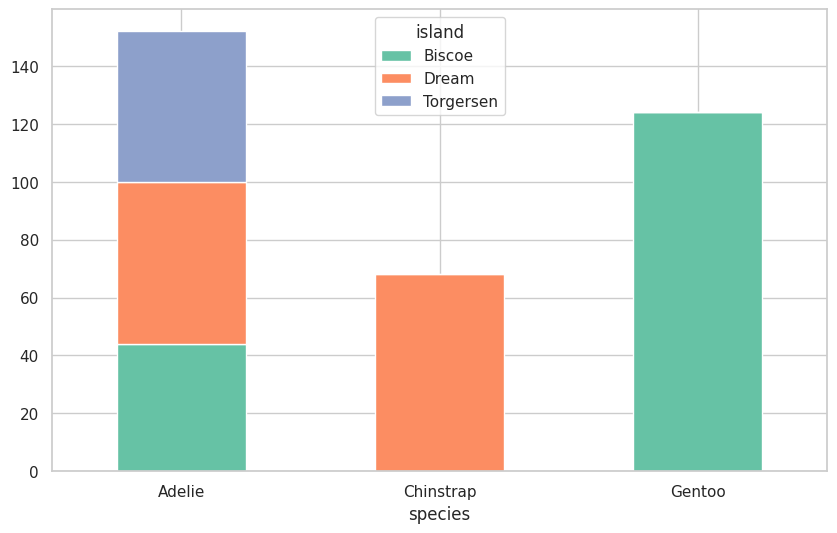

In [25]:
# Visualizing the data

data.groupby(['species', 'island']).size().unstack().plot(kind='bar', stacked=True, figsize=(10, 6), rot=0)

In [26]:
# Preparing the data

island_species = data.groupby(['species', 'island']).size().unstack().fillna(0)
print(island_species)

# Running the Chi-Square test of independence
chi_statistic, p_value, dof, blueprint_matrix= stats.chi2_contingency(island_species)
print(f"\nChi-Square Test: {chi_statistic:.2f} and P-Value: {p_value:.4%}")
print(blueprint_matrix)


island     Biscoe  Dream  Torgersen
species                            
Adelie       44.0   56.0       52.0
Chinstrap     0.0   68.0        0.0
Gentoo      124.0    0.0        0.0

Chi-Square Test: 299.55 and P-Value: 0.0000%
[[74.23255814 54.79069767 22.97674419]
 [33.20930233 24.51162791 10.27906977]
 [60.55813953 44.69767442 18.74418605]]


The blueprint matrix shows how the table would look IF they would be independent and since the p_value is 0, we conclude that there is a relationship between these two categorical variables.

### Hypothesis testing - Goodness of fit

HIstorically, the ratios among species in the Palmer islands have been Adelie with 50%, Chinstrap with 20% and Gentoo with 30%. Ae the rations the same?



In [27]:
pen_obs = data.species.value_counts().values
total_penguins = data.species.dropna().shape[0]
print(pen_obs)

expected_ratio = np.array([0.5, 0.3, 0.2]) * total_penguins
statistic, p_value = stats.chisquare(pen_obs, expected_ratio)
print(f'The Chi-Square statistic is {statistic:.2f} and the p-value is {p_value:.4%}.')

[152 124  68]
The Chi-Square statistic is 6.53 and the p-value is 3.8252%.


The proportions have changed since the p_value is under 5%. Hence, H0 is rejected

## Linear regression

#### Simple Linear Regression

<Axes: xlabel='body_mass_g', ylabel='Count'>

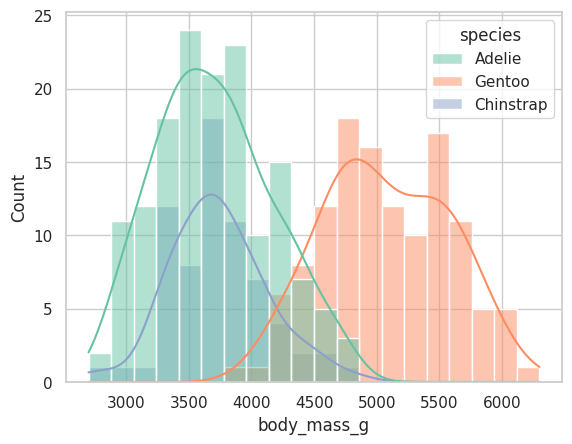

In [47]:
# Visualizing body mass

sns.histplot(data=data, x='body_mass_g', kde=True, bins=20, color='red', hue='species', legend=True, alpha=0.5)

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          4.37e-107
Time:                        23:06:15   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -5780.8314    305.81

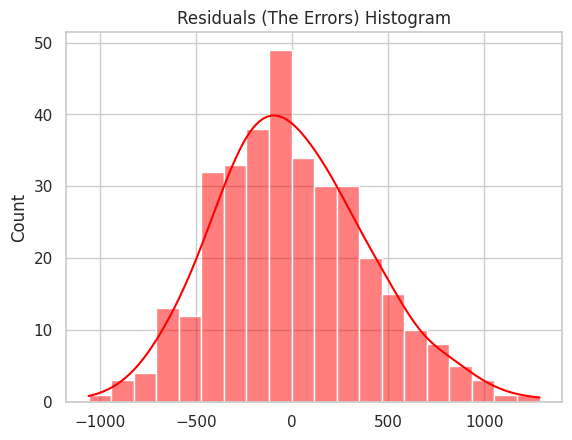

In [72]:
# Using the OLS method - One-variable regression

X_raw = data.flipper_length_mm.dropna()
y = data.body_mass_g.dropna()

# Adding a constant to the model
X = sm.add_constant(X_raw)
# Fitting the model
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

y_hat = ols_model.predict(X)

# Calculating the error
error = y - y_hat
sns.histplot(error, kde=True, bins=20, color='red', legend=True, alpha=0.5)
plt.title('Residuals (The Errors) Histogram')

rmse = np.sqrt(mean_squared_error(y, y_hat))
print(f'\nThe RMSE is {rmse:.2f}')
# sns.histplot(rmse, kde=True, bins=20, color='red', legend=True, alpha=0.5)

The F statistic p_value is 0 so the model is statistically significant. Same for the coefficient and the constant.

Text(0.5, 1.0, 'Actual Data (Scatter Plot) and OLS Regression Line')

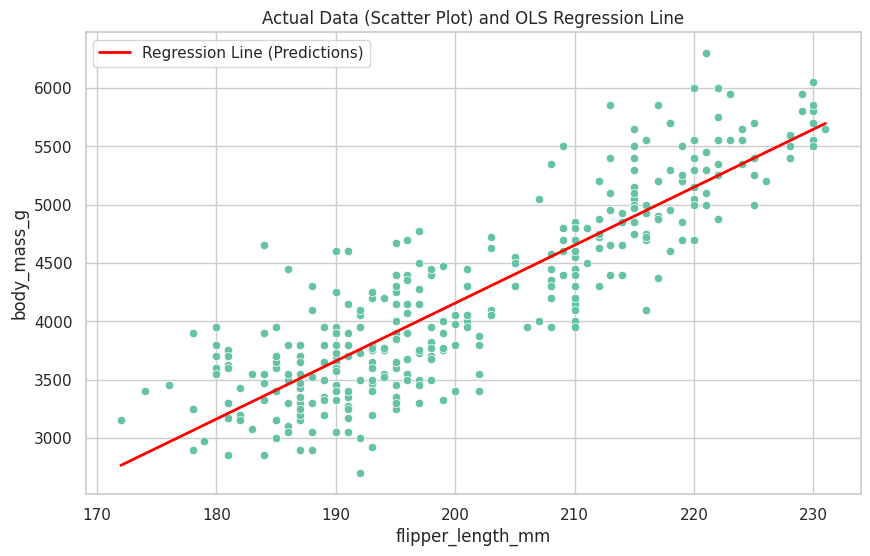

In [87]:
import matplotlib.pyplot as plt

# Create a large, clean figure
plt.figure(figsize=(10, 6))

# 1. Plot the Actual Data (Scatter Plot)
sns.scatterplot(x=X_raw, y=y)

# 2. Plot the OLS Regression Line
sns.lineplot(x=X_raw, y=y_hat, color='red', linewidth=2, label='Regression Line (Predictions)')

plt.title('Actual Data (Scatter Plot) and OLS Regression Line')


Text(0.5, 1.0, 'Residuals (The Errors) Scatter Plot')

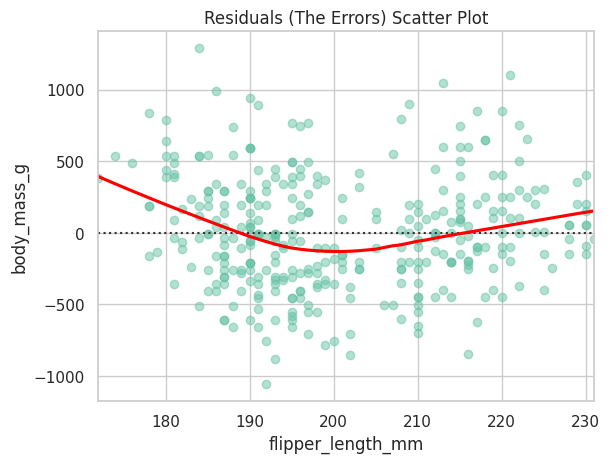

In [84]:
# Scatter plot of the residuals - OLS by the Seaboorn Residuals Plot using OLS
sns.residplot(x=x_raw, y=y, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Residuals (The Errors) Scatter Plot')

In [114]:
# Using MLE

X_mle = X_raw.to_numpy().reshape(-1, 1)
model = linear_model.LinearRegression()
model.fit(X_mle, y)
coefficient = model.coef_
intercept = model.intercept_
y_pred = model.predict(X_mle)

R2 = model.score(X_mle, y)
print(f'R2: {R2:.2f}')

RMSE = np.sqrt(mean_squared_error(y, y_pred))
print(f'RMSE: {RMSE:.2f}')

print(f'The coefficient is {coefficient[0]} and the intercept is {intercept:.2f}.')

R2: 0.76
RMSE: 393.12
The coefficient is 49.68556640610011 and the intercept is -5780.83.


Usually, experimentation is done with Statsmodel and production with SKLearn. ALso note that SKLearn uses MLE behind the scenes. The difference in output between statsmodels and sklearn is due to sklearn more focused on the prediction values

#### Multi Linear Regression

## Classification

# DRAFT

In [97]:
type(X_raw.to_numpy())
test = X_raw.to_numpy()
# print(test)

print(test.reshape(-1, 1))

[[181.]
 [186.]
 [195.]
 [193.]
 [190.]
 [181.]
 [195.]
 [193.]
 [190.]
 [186.]
 [180.]
 [182.]
 [191.]
 [198.]
 [185.]
 [195.]
 [197.]
 [184.]
 [194.]
 [174.]
 [180.]
 [189.]
 [185.]
 [180.]
 [187.]
 [183.]
 [187.]
 [172.]
 [180.]
 [178.]
 [178.]
 [188.]
 [184.]
 [195.]
 [196.]
 [190.]
 [180.]
 [181.]
 [184.]
 [182.]
 [195.]
 [186.]
 [196.]
 [185.]
 [190.]
 [182.]
 [179.]
 [190.]
 [191.]
 [186.]
 [188.]
 [190.]
 [200.]
 [187.]
 [191.]
 [186.]
 [193.]
 [181.]
 [194.]
 [185.]
 [195.]
 [185.]
 [192.]
 [184.]
 [192.]
 [195.]
 [188.]
 [190.]
 [198.]
 [190.]
 [190.]
 [196.]
 [197.]
 [190.]
 [195.]
 [191.]
 [184.]
 [187.]
 [195.]
 [189.]
 [196.]
 [187.]
 [193.]
 [191.]
 [194.]
 [190.]
 [189.]
 [189.]
 [190.]
 [202.]
 [205.]
 [185.]
 [186.]
 [187.]
 [208.]
 [190.]
 [196.]
 [178.]
 [192.]
 [192.]
 [203.]
 [183.]
 [190.]
 [193.]
 [184.]
 [199.]
 [190.]
 [181.]
 [197.]
 [198.]
 [191.]
 [193.]
 [197.]
 [191.]
 [196.]
 [188.]
 [199.]
 [189.]
 [189.]
 [187.]
 [198.]
 [176.]
 [202.]
 [186.]
 [199.]


In [37]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


In [28]:
data.island.unique()

<StringArray>
['Torgersen', 'Biscoe', 'Dream']
Length: 3, dtype: str

In [29]:
data.species.value_counts(normalize=True)

species
Adelie       0.441860
Gentoo       0.360465
Chinstrap    0.197674
Name: proportion, dtype: float64

In [36]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     343.6
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           2.89e-82
Time:                        21:34:34   Log-Likelihood:                -2582.3
No. Observations:                 342   AIC:                             5171.
Df Residuals:                     339   BIC:                             5182.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                3700.6623     37.619     98.371      0.000    3626.665    3774.659
C(species)[T.Chinstrap]    32.4260     67.512      0.480      0.631    -100.369     165.221
C(species)[T.Gentoo]     1375.3540     56.148     24.495      0.000    1264.912    1485.796
==============================================================================
Omnibus:                        7.340   Durbin-Watson:                   3.036
Prob(Omnibus):                  0.025   Jarque-Bera (JB):                5.331
Skew:                           0.182   Prob(JB):                       0.0696
Kurtosis:                       2.508   Cond. No.                         3.45
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [31]:
data.species.value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [32]:
data[data.body_mass_g.isna()]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,2009


In [33]:
data.query('species == "Gentoo"').shape[0]

124

In [34]:
data.query('species == "Adelie"').body_mass_g.mean()

np.float64(3700.662251655629)